# 09. 결과만 있고 사건이 없었다 — 기업행위 이벤트 표 (v16)

> 2026-09-10 · 이동원 · 결론 문서:
> [기능명세 v1.8 기업행위 이벤트 표](../../docs/기능명세/version1.8/기업행위_이벤트_표.md) ·
> [데이터파트 v4.4](../../docs/데이터파트/version4.4/명세서.md) (D-24 닫음)

우리 시세에는 **조정 결과**만 있었습니다. `adj_close` 는 이미 펴진 값이고 `adj_source` 는
그 값이 어디서 왔는지만 말합니다. *"무슨 일이 언제 얼마만큼 일어났나"* 는 어디에도 없어서,
물을 때마다 923만 행을 훑으며 `adjustment_factor` 로 역산해야 했습니다(4분).

zipline 이 `splits`·`mergers`·`dividends` 를 따로 두는 이유가 이것입니다 — **조정된 가격과
조정을 일으킨 사건은 다른 자료**입니다. 배당은 v14 에서 이미 표가 됐으므로, 이 노트북은
나머지 자본 사건을 표로 세우고 **기존 판정(chain)과 대조해 어긋난 건수를 셉니다.**

이 노트북이 답하는 것 여섯입니다.

1. 두 출처 중 하나는 **독립이 아니었다** — 무엇을 대조에 쓸 수 있나
2. 액면가만 보면 **42건을 10배 망친다** — 자본금으로 갈라야 뜻이 생긴다
3. 대조 결과 — 판정 가능 730건 중 어긋남 8건
4. 🔴 **초록 3,974건이 무의미했다** — 검사가 대상과 같은 값을 쓰면
5. 문턱은 **분포가 정한다** — 88,700배짜리 빈 구간
6. 자기모순 17건 — 전부 정리매매이고, 값을 고치지 않는 이유

In [1]:
import sqlite3
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from matplotlib import font_manager

ROOT = Path.cwd()
while not (ROOT / "supply").exists():
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT))

from common.paths import krx_db_path                              # noqa: E402, I001

pd.set_option("display.width", 160)
pd.set_option("display.max_columns", 40)


def 한글폰트_설정() -> str:
    """한글 폰트를 잡고 **깨짐을 막는다.** 세 가지를 다 해야 안 깨진다.

    ① **한글 폰트** — 없으면 제목·축이름이 전부 □ 로 나온다.
    ② **fallback 체인** — 맑은 고딕에는 U+2212(−)가 **없다**(실측). 로그 축의 10⁻³ 은
       mathtext 로 그려지고 거기서 두부가 났다.
    ③ `axes.unicode_minus = False` — 일반 축 눈금의 마이너스를 ASCII 하이픈으로.
    """
    후보 = ["Malgun Gothic", "NanumGothic", "NanumBarunGothic", "AppleGothic",
            "Noto Sans CJK KR", "Gulim"]
    있는것 = {f.name for f in font_manager.fontManager.ttflist}
    찾음 = next((n for n in 후보 if n in 있는것), None)
    if 찾음 is None:
        print("🔴 한글 폰트가 없다 — 그림의 한글이 □ 로 나온다. 할 일:\n"
              "   Colab·Linux : !apt-get install -y fonts-nanum && fc-cache -fv\n"
              "   Windows     : 맑은 고딕은 기본 설치다 (캐시가 낡았으면\n"
              "                 font_manager._load_fontmanager(try_read_cache=False))")
        return ""
    plt.rcParams["font.family"] = [찾음, "DejaVu Sans"]
    plt.rcParams["axes.unicode_minus"] = False
    plt.rcParams["figure.dpi"] = 110
    return 찾음


def 로그축_ASCII(ax, axis: str = "y") -> None:
    """로그 축의 지수를 ASCII 로 다시 쓴다 — mathtext 의 U+2212 를 피한다."""
    축 = ax.yaxis if axis == "y" else ax.xaxis
    축.set_major_formatter(plt.FuncFormatter(lambda v, _: f"{v:g}"))


폰트 = 한글폰트_설정()
con = sqlite3.connect(krx_db_path())
con.execute("PRAGMA cache_size = -400000")
print(f"한글 폰트: {폰트 or '없음'}")
print(f"DB: {krx_db_path()}  ·  스키마 v"
      f"{con.execute('PRAGMA user_version').fetchone()[0]}")

한글 폰트: Malgun Gothic
DB: C:\Users\kik32\workspace\EST-Camp-AI-Quant\team_project\Alpha_Stack\data\krx_cache.db  ·  스키마 v16


---

## 1. 두 출처 중 하나는 독립이 아니었습니다

설계할 때는 `stock_base_info` 를 **독립 출처**로 잡았습니다. 시세(`daily_price`)와 다른
API 에서 오니 서로 대조할 수 있으리라 본 것입니다. 먼저 그것부터 확인합니다.

In [2]:
겹침 = con.execute("""
    SELECT COUNT(*) AS 겹치는행,
           SUM(d.listed_shares = b.list_shrs) AS 주식수일치,
           SUM(d.listed_shares IS NULL) AS daily결측,
           SUM(b.list_shrs IS NULL) AS base결측
    FROM daily_price d
    JOIN stock_base_info b ON d.code = b.code AND d.bas_dd = b.bas_dd
""").fetchone()
행, 일치, dn, bn = 겹침
print(f"겹치는 (code, bas_dd)   {행:>12,}")
print(f"주식수가 같은 행         {일치:>12,}   ({일치 / 행 * 100:.4f}%)")
print(f"결측  daily {dn} · base {bn}")

겹치는 (code, bas_dd)      9,229,173
주식수가 같은 행            9,229,173   (100.0000%)
결측  daily 0 · base 0


**923만 행 전부 같습니다.** `stock_base_info.list_shrs` 는 `daily_price.listed_shares` 와
같은 값을 다른 표에 두 번 적어 둔 것이라, **대조에 쓸 수 없습니다.**

그러면 `stock_base_info` 가 홀로 주는 것은 무엇인가 — 종목마다 연속한 두 스냅샷에서
무엇이 바뀌는지 세어 봅니다.

In [3]:
변경 = pd.read_sql_query("""
    SELECT SUM(parval  IS NOT 앞액면) AS 액면가,
           SUM(list_dd IS NOT 앞상장) AS 상장일,
           SUM(isin_cd IS NOT 앞ISIN) AS ISIN
    FROM (
      SELECT parval, list_dd, isin_cd,
             LAG(parval)  OVER w AS 앞액면,
             LAG(list_dd) OVER w AS 앞상장,
             LAG(isin_cd) OVER w AS 앞ISIN
      FROM stock_base_info
      WINDOW w AS (PARTITION BY code ORDER BY bas_dd)
    ) WHERE 앞액면 IS NOT NULL OR 앞상장 IS NOT NULL OR 앞ISIN IS NOT NULL
""", con)
display(변경.T.rename(columns={0: "변경 건수"}))

,변경 건수
액면가,792
상장일,24
ISIN,0


`isin_cd` 는 **한 번도 안 바뀝니다**(0건). 우리 구간에서는 쓸모가 없습니다.
남는 것은 **액면가 792건**과 **상장일 24건**입니다.

### 상장일 24건이 짚은 것

`adjustment_factor` 의 docstring 에는 *"알려진 결함"* 이 하나 적혀 있었습니다 — 두 행만
보는 함수라 거래일 공백을 못 봐서, 상장폐지된 회사의 마지막 종가와 몇 년 뒤 **다른 회사**의
기준가로 배율을 만든다는 것입니다. 상장일 변경 24건이 그 자리를 정확히 짚습니다.

In [4]:
상장일변경 = pd.read_sql_query("""
    SELECT code, bas_dd AS 적용일, 앞상장 AS 이전_상장일, list_dd AS 새_상장일,
           앞시장 AS 이전_시장, market AS 새_시장
    FROM (
      SELECT code, bas_dd, list_dd, market,
             LAG(list_dd) OVER w AS 앞상장, LAG(market) OVER w AS 앞시장
      FROM stock_base_info
      WINDOW w AS (PARTITION BY code ORDER BY bas_dd)
    ) WHERE 앞상장 IS NOT NULL AND list_dd IS NOT 앞상장
    ORDER BY 적용일
""", con)
상장일변경["시장이_바뀌나"] = 상장일변경["이전_시장"] != 상장일변경["새_시장"]
print(f"상장일 변경 {len(상장일변경)}건 · 그중 시장이 안 바뀐 것 "
      f"{(~상장일변경['시장이_바뀌나']).sum()}건\n")
display(상장일변경[~상장일변경["시장이_바뀌나"]])
print("↑ 시장이 그대로인 두 건이 곧 **코드 재사용**입니다 — 공백이 8년·10년입니다.")
print("  나머지 22건은 코스닥→유가 이전상장이라 공백이 없고, 가격도 이어집니다.")

상장일 변경 24건 · 그중 시장이 안 바뀐 것 2건



,code,적용일,이전_상장일,새_상장일,이전_시장,새_시장,시장이_바뀌나
21,036220,20240313,20070605,20240313,KOSDAQ,KOSDAQ,False
23,101970,20250328,20120726,20250328,KOSDAQ,KOSDAQ,False


↑ 시장이 그대로인 두 건이 곧 **코드 재사용**입니다 — 공백이 8년·10년입니다.
  나머지 22건은 코스닥→유가 이전상장이라 공백이 없고, 가격도 이어집니다.


`is_series_restart` 는 **공백 + 새 상장일** 둘을 함께 봅니다. 그래서 24건 중 정확히 이
2건만 끊고, 이전상장 22건은 통과시킵니다. 표에서도 그렇게 갈립니다(§3).

---

## 2. 액면가만 보면 42건을 10배 망칩니다

액면가 비율은 매력적인 증거입니다 — 5,000 → 500 이면 가격이 정확히 1/10 이 되고, **단수주
반올림이 없는 정확한 정수비**입니다. 그런데 그대로 쓰면 안 됩니다. 자본금(`액면가 × 주식수`)
으로 갈라 봅니다.

In [5]:
갈래 = pd.read_sql_query("""
    SELECT event_type AS 종류, COUNT(*) AS 행,
           SUM(ratio_num IS NOT NULL) AS 배율있음,
           SUM(agrees = 1) AS 맞음, SUM(agrees = 0) AS 어긋남,
           SUM(agrees IS NULL) AS 못잼
    FROM corporate_action GROUP BY 1 ORDER BY 2 DESC
""", con)
설명 = {"split_merge": "액면분할·병합 (자본금 불변)",
      "rights_off": "권리락·주식배당 (기준가만)",
      "resume_revalue": "재개일 재평가 (KRX 단일가)",
      "par_reduction": "액면가 감액 (주식수 그대로)",
      "series_restart": "시계열 재시작 (다른 회사)",
      "market_transfer": "이전상장 (시장만)",
      "share_change": "주식수 변동 (유상증자 등)"}
갈래["설명"] = 갈래["종류"].map(설명)
display(갈래)
print(f"합계 {갈래['행'].sum():,}행")

,종류,행,배율있음,맞음,어긋남,못잼,설명
0,share_change,39584,0,NaN,NaN,39584,주식수 변동 (유상증자 등)
1,rights_off,3191,3191,NaN,NaN,3191,권리락·주식배당 (기준가만)
2,resume_revalue,783,783,NaN,NaN,783,재개일 재평가 (KRX 단일가)
3,split_merge,666,666,662.0,4.0,0,액면분할·병합 (자본금 불변)
4,par_reduction,42,0,42.0,0.0,0,액면가 감액 (주식수 그대로)
5,market_transfer,22,0,18.0,4.0,0,이전상장 (시장만)
6,series_restart,2,0,NaN,NaN,2,시계열 재시작 (다른 회사)


합계 44,290행


In [6]:
# 액면가가 바뀐 792건이 어디로 갔나 — 자본금이 갈랐다
액면 = pd.read_sql_query("""
    SELECT event_type AS 종류, COUNT(*) AS 행
    FROM corporate_action
    WHERE par_before IS NOT NULL AND par_after IS NOT NULL
      AND par_before <> par_after
    GROUP BY 1 ORDER BY 2 DESC
""", con)
display(액면)
print(f"액면가가 바뀐 사건 {액면['행'].sum()}건")
print()
print("`par_reduction` 42건은 **액면가만 줄고 주식수는 그대로**입니다 —")
print("결손금을 턴 것이라 주주가 가진 주식 수도 회사도 그대로이고, **가격이 안 움직입니다.**")
print("여기에 액면가 비율(1/10)을 적용했다면 멀쩡한 과거를 10배 망쳤을 것입니다.")

,종류,행
0,split_merge,666
1,resume_revalue,75
2,par_reduction,42
3,share_change,9


액면가가 바뀐 사건 792건

`par_reduction` 42건은 **액면가만 줄고 주식수는 그대로**입니다 —
결손금을 턴 것이라 주주가 가진 주식 수도 회사도 그대로이고, **가격이 안 움직입니다.**
여기에 액면가 비율(1/10)을 적용했다면 멀쩡한 과거를 10배 망쳤을 것입니다.


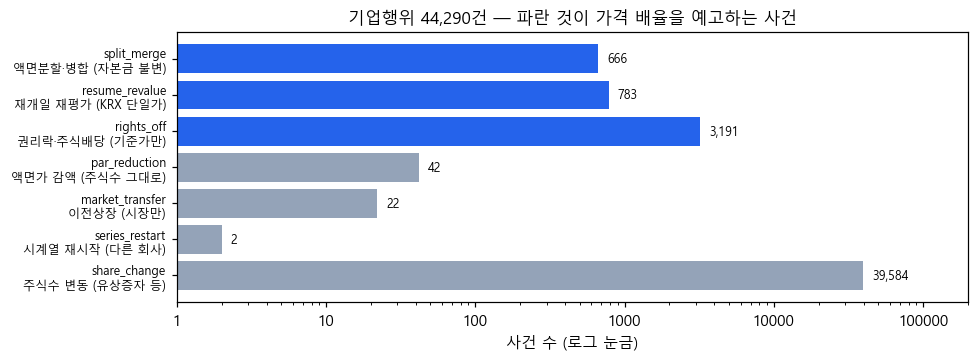

In [7]:
fig, ax = plt.subplots(figsize=(9, 3.4))
순서 = ["split_merge", "resume_revalue", "rights_off", "par_reduction",
      "market_transfer", "series_restart", "share_change"]
표 = 갈래.set_index("종류").reindex(순서)
색 = ["#2563eb" if v else "#94a3b8" for v in (표["배율있음"] > 0)]
바 = ax.barh(range(len(표)), 표["행"], color=색)
ax.set_yticks(range(len(표)))
ax.set_yticklabels([f"{t}\n{설명[t]}" for t in 순서], fontsize=8)
ax.invert_yaxis()
ax.set_xscale("log")
로그축_ASCII(ax, "x")
ax.set_xlabel("사건 수 (로그 눈금)")
ax.set_title("기업행위 44,290건 — 파란 것이 가격 배율을 예고하는 사건", fontsize=11)
for r, v in zip(바, 표["행"], strict=True):
    ax.text(v * 1.15, r.get_y() + r.get_height() / 2, f"{v:,}",
            va="center", fontsize=8)
ax.set_xlim(1, 200000)
fig.tight_layout()
plt.show()

막대가 파란 것(`split_merge`·`resume_revalue`·`rights_off`)만 배율을 냅니다. 나머지는
**가격이 연속인 사건**이라 배율 칸을 비웁니다 — 여기에 1 을 적으면 쓰는 쪽이 곱해 버립니다.

---

## 3. 🔴 초록 3,974건이 무의미했습니다

처음에는 배율이 있는 사건을 **전부** chain 계수와 대조했습니다. 결과가 이랬습니다.

| 종류 | 행 | 맞음 |
|---|---:|---:|
| `rights_off` | 3,191 | **3,191** |
| `resume_revalue` | 783 | **783** |

전부 맞았습니다. 당연합니다 — 이 둘은 배율을 `adjustment_factor` 에서 얻는데 그것을 다시
`factor_series` 와 견줬습니다. **검사가 대상과 같은 값을 씁니다.**

이 함정은 이미 아는 것이었습니다. `series_restart` 에는 피해 놓고(같은 `is_series_restart`
를 공유하므로) basis 갈래에서 그대로 밟았습니다. 그래서 **chain 이 배율 계산에 쓰지 않는
축만** 재도록 좁혔습니다 — 액면가와 상장일입니다.

In [8]:
잴수있는 = pd.read_sql_query("""
    SELECT source AS 증거축, COUNT(*) AS 행,
           SUM(agrees IS NOT NULL) AS 판정가능,
           SUM(agrees = 0) AS 어긋남
    FROM corporate_action GROUP BY 1 ORDER BY 3 DESC
""", con)
잴수있는["chain 이 이 축을 쓰나"] = 잴수있는["증거축"].map({
    "par": "안 쓴다 — 독립이다",
    "listing": "재시작 판정에만 쓴다 (이전상장은 안 쓴다)",
    "basis": "🔴 이것이 곧 chain 이다",
    "shares": "㉠ 갈래에서 쓴다 · 애초에 배율을 예고하지 않는다",
})
display(잴수있는)
합 = pd.read_sql_query(
    "SELECT COUNT(*) 전체, SUM(agrees IS NOT NULL) 판정가능, "
    "SUM(agrees=1) 맞음, SUM(agrees=0) 어긋남 FROM corporate_action", con)
display(합)

,증거축,행,판정가능,어긋남,chain 이 이 축을 쓰나
0,par,708,708,4.0,안 쓴다 — 독립이다
1,listing,24,22,4.0,재시작 판정에만 쓴다 (이전상장은 안 쓴다)
2,shares,39584,0,NaN,㉠ 갈래에서 쓴다 · 애초에 배율을 예고하지 않는다
3,basis,3974,0,NaN,🔴 이것이 곧 chain 이다


,전체,판정가능,맞음,어긋남
0,44290,730,722,8


### 어긋난 8건 전수

In [9]:
어긋남 = pd.read_sql_query("""
    SELECT ca.code, ca.ex_date AS 적용일, d.name AS 이름, ca.event_type AS 종류,
           ca.ratio_num || '/' || ca.ratio_den AS 증거배율,
           COALESCE(ca.chain_num || '/' || ca.chain_den, '없음') AS chain,
           ROUND(ca.basis_ratio, 6) AS 기준가비,
           ca.is_liquidation AS 정리매매
    FROM corporate_action ca
    JOIN daily_price d ON d.code = ca.code AND d.bas_dd = ca.ex_date
    WHERE ca.agrees = 0 ORDER BY ca.ex_date
""", con)
display(어긋남)

,code,적용일,이름,종류,증거배율,chain,기준가비,정리매매
0,084810,20100323,아이알디,split_merge,10/1,없음,1.000000,1
1,031440,20100429,신세계푸드,market_transfer,NaN,885/818,1.081907,0
2,055250,20100917,다휘,split_merge,1/5,없음,1.000000,1
3,030790,20101102,동양시스템즈,market_transfer,NaN,153/154,0.993506,0
4,035720,20170710,카카오,market_transfer,NaN,255/254,1.003937,0
5,068270,20180209,셀트리온,market_transfer,NaN,2715/2714,1.000368,0
6,221610,20200429,자안,split_merge,1/5,1/25,0.040000,0
7,309930,20260527,조이웍스앤코,split_merge,5/1,281/221,1.271493,0


여덟 자리가 **네 갈래**입니다.

| 자리 | 무엇인가 | 판정 |
|---|---|---|
| `084810` · `055250` | 정리매매 재개일 — KRX 가 기준가를 안 고쳤다 | §5 에서 다시 본다 |
| `221610` · `309930` | 재개일 재평가 — 액면분할 **말고도** 무슨 일이 더 있었다 | chain 이 맞다 |
| `030790` · `035720` · `068270` | 이전상장 — 기준가가 **1 틱** 다르다 (0.04~0.4%) | 호가단위 차이 |
| `031440` | 이전상장인데 기준가가 **8.2%** 다르다 | 남겨 둔다 |

앞의 셋은 사건을 **더 잘 설명한 쪽이 chain** 이라 표가 배율을 고치지 않습니다. 이 표의
일은 판정을 바꾸는 것이 아니라 **어긋난 자리를 남기는 것**입니다.

---

## 4. 문턱은 분포가 정합니다

`split_merge` 666건에서 액면가가 예고한 배율과 chain 계수가 얼마나 벌어지는지 전수로
재 봅니다. 문턱을 먼저 정하고 세면 원하는 답이 나옵니다 — **거꾸로 합니다.**

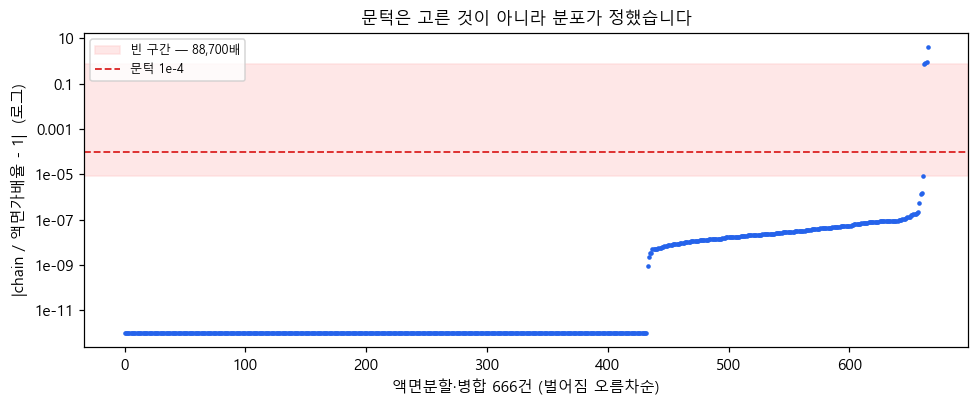

0 인 것(정확히 일치)       433건
빈 구간 아래              229건
빈 구간 위 (어긋남)          4건


In [10]:
sm = pd.read_sql_query("""
    SELECT code, ex_date, ratio_num, ratio_den, chain_num, chain_den,
           shares_before, shares_after, par_before, par_after, is_liquidation
    FROM corporate_action WHERE event_type = 'split_merge'
""", con)
증거 = sm["ratio_num"] / sm["ratio_den"]
체인 = np.where(sm["chain_num"].notna(), sm["chain_num"] / sm["chain_den"], 1.0)
sm["벌어짐"] = np.abs(체인 / 증거 - 1)
sm["주식수비"] = sm["shares_after"] / sm["shares_before"]
정렬 = sm.sort_values("벌어짐").reset_index(drop=True)

fig, ax = plt.subplots(figsize=(9, 3.8))
y = 정렬["벌어짐"].replace(0, 1e-12)        # 로그 축에 0 을 올릴 수 없다
ax.plot(range(len(y)), y, ".", ms=4, color="#2563eb")
ax.set_yscale("log")
로그축_ASCII(ax, "y")
ax.axhspan(8.408e-06, 7.457e-01, color="#fecaca", alpha=0.45,
           label="빈 구간 — 88,700배")
ax.axhline(1e-4, color="#dc2626", lw=1.2, ls="--", label="문턱 1e-4")
ax.set_xlabel("액면분할·병합 666건 (벌어짐 오름차순)")
ax.set_ylabel("|chain / 액면가배율 - 1|  (로그)")
ax.set_title("문턱은 고른 것이 아니라 분포가 정했습니다", fontsize=11)
ax.legend(fontsize=8, loc="upper left")
fig.tight_layout()
plt.show()

벌 = 정렬["벌어짐"]
print(f"0 인 것(정확히 일치)      {(벌 == 0).sum():>4}건")
print(f"빈 구간 아래             {((벌 > 0) & (벌 <= 8.408e-06)).sum():>4}건")
print(f"빈 구간 위 (어긋남)       {(벌 > 7.457e-01).sum():>4}건")

빈 구간 아래 662건은 **전부 단수주**입니다. chain 은 재개일에 주식수 배율을 쓰는데(`㉠`)
그 비율이 정수가 아닙니다 — 액면가만 KRX 가 정한 정확한 정수비입니다.

In [11]:
근처 = 정렬[(정렬["벌어짐"] > 0) & (정렬["벌어짐"] <= 8.408e-06)].tail(6)
근처 = 근처[["code", "ex_date", "par_before", "par_after", "주식수비", "벌어짐"]]
근처["액면가배율"] = (근처["par_after"].astype(float)
                / 근처["par_before"].astype(float))
display(근처.assign(주식수비=근처["주식수비"].map("{:.10g}".format),
                  벌어짐=근처["벌어짐"].map("{:.3e}".format)))
print("↑ 주식수비가 0.1999999658 인데 액면가배율은 정확히 0.2 입니다 — 4주 차이입니다.")

,code,ex_date,par_before,par_after,주식수비,벌어짐,액면가배율
656,012170,20260828,500,2500,0.1999999605,1.975e-07,5.0
657,025560,20210430,100,500,0.1999999571,2.143e-07,5.0
658,048260,20230725,500,5000,0.09999994864,5.136e-07,10.0
659,032685,20230503,500,200,2.4999965,1.400e-06,0.4
660,021045,20221223,500,5000,0.09999985857,1.414e-06,10.0
661,032685,20260526,200,1000,0.1999983184,8.408e-06,5.0


↑ 주식수비가 0.1999999658 인데 액면가배율은 정확히 0.2 입니다 — 4주 차이입니다.


---

## 5. 자기모순 17건 — 전부 정리매매입니다

§3 에서 basis 갈래는 순환이라 못 잰다고 했습니다. 그러면 그쪽은 아무것도 못 보나 —
**chain 을 안 쓰고 재는 축이 하나 있습니다.** 원본 두 칸이 서로 모순인지 보는 것입니다.

> 주식수가 1.5배 밖으로 바뀌었는데, 그 날 KRX 등락률이 **가격제한폭 밖**이다.

같은 원본이 *"주식수가 1,500분의 1 이 됐는데 가격은 그 폭만큼 움직였다"* 고 말하는 셈입니다.
chain 이 무엇을 골랐는지와 무관합니다.

In [12]:
모순 = pd.read_sql_query("""
    SELECT ca.code, ca.ex_date AS 적용일, d.name AS 이름, ca.event_type AS 종류,
           ROUND(CAST(ca.shares_after AS REAL) / ca.shares_before, 8) AS 주식수비,
           ca.basis_ratio AS 기준가비, ROUND(d.change_rate, 2) AS 등락률,
           d.market AS 시장, ca.is_liquidation AS 정리매매
    FROM corporate_action ca
    JOIN daily_price d ON d.code = ca.code AND d.bas_dd = ca.ex_date
    WHERE ca.source_conflict = 1 ORDER BY ca.ex_date
""", con)
display(모순)
print(f"{모순['정리매매'].sum()}/{len(모순)}건이 정리매매입니다.")

,code,적용일,이름,종류,주식수비,기준가비,등락률,시장,정리매매
0,047940,20100120,비엔디,share_change,0.050000,1.0,163.16,KOSDAQ,1
1,084810,20100323,아이알디,split_merge,0.100000,1.0,-66.67,KOSDAQ,1
2,068770,20100608,선우중공업,share_change,0.033333,1.0,266.67,KOSDAQ,1
3,018890,20100713,모라리소스,share_change,0.333333,1.0,-69.93,KOSDAQ,1
4,058690,20100817,퓨쳐인포넷,share_change,0.250000,1.0,-71.43,KOSDAQ,1
5,055250,20100917,다휘,split_merge,5.000000,1.0,-98.08,KOSDAQ,1
6,047600,20110831,세계투어,share_change,0.050000,1.0,406.45,KOSDAQ,1
7,002670,20120405,미주제강,share_change,0.250000,1.0,-62.27,KOSDAQ,1
8,040740,20120420,아인스M&M,resume_revalue,0.533930,1.0,-93.58,KOSDAQ,1
9,037240,20120522,평안물산,share_change,0.100000,1.0,83.96,KOSDAQ,1


17/17건이 정리매매입니다.


**17/17 이 정리매매이고, 17건 전부 기준가비가 정확히 1 입니다.** 우연이 아닙니다 —
`LIQUIDATION_DAYS` 주석이 이미 적어 둔 사실입니다:

> 한국은 상장폐지가 확정되면 통상 **7거래일간 정리매매**를 하는데 **그 구간만 가격제한폭이
> 적용되지 않는다.**

그래서 "등락률이 폭 밖" 은 원본 오류가 아니라 정상 동작입니다. 그 자리들이 정말 종목의
끝자락인지 그림으로 확인합니다.

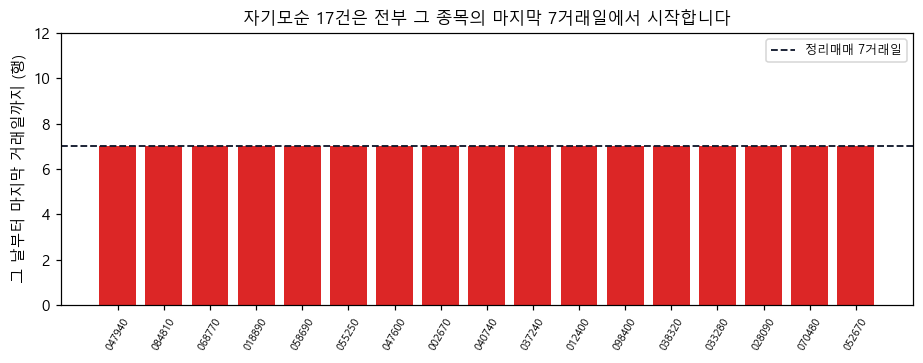

그날부터_끝까지
7    17


In [13]:
위치 = []
for code, dd in zip(모순["code"], 모순["적용일"], strict=True):
    전체, = con.execute(
        "SELECT COUNT(*) FROM daily_price WHERE code = ?", (code,)).fetchone()
    뒤, = con.execute(
        "SELECT COUNT(*) FROM daily_price WHERE code = ? AND bas_dd >= ?",
        (code, dd)).fetchone()
    위치.append({"code": code, "전체행": 전체, "그날부터_끝까지": 뒤})
위치표 = pd.DataFrame(위치)

fig, ax = plt.subplots(figsize=(8.5, 3.4))
ax.bar(range(len(위치표)), 위치표["그날부터_끝까지"], color="#dc2626")
ax.axhline(7, color="#0f172a", lw=1.2, ls="--", label="정리매매 7거래일")
ax.set_xticks(range(len(위치표)))
ax.set_xticklabels(위치표["code"], rotation=60, fontsize=7)
ax.set_ylabel("그 날부터 마지막 거래일까지 (행)")
ax.set_ylim(0, 12)
ax.set_title("자기모순 17건은 전부 그 종목의 마지막 7거래일에서 시작합니다", fontsize=11)
ax.legend(fontsize=8)
fig.tight_layout()
plt.show()
print(위치표["그날부터_끝까지"].value_counts().to_string())

**17건 모두 정확히 7행입니다.** 표를 세우기 전에는 이것이 *"조정을 놓친 15건"* 으로 보였는데,
전수로 세고 위치를 재 보니 **하나의 사건 종류**였습니다.

### 그래서 값을 고치지 않습니다

셋 다 확인하고 내린 결론입니다.

1. **원본 오류가 아니다** — 정리매매 구간에는 가격제한폭이 없다. KRX 가 그 구간의 기준가를
   안 고칠 뿐이다.
2. **이미 덮여 있다** — 17건 전부 `is_liquidation` 이고, `training_frame` 이 기본으로
   덜어낸다. **학습 표본으로 새는 것은 0건**이다.
3. **고치면 손해다** — 수정주가를 다시 만들면 FDR 창이 밀린 만큼 옛 행이 `chain` 으로
   내려앉는다. 전부 상장폐지된 종목이라 얻는 것이 없다.

그래서 `source_conflict = 1` 로 **표시만** 합니다. 나중에 정리매매로 설명되지 않는 자리가
생기면 빌더가 그 자리에서 붉은불을 켭니다.

In [14]:
# 가장 극단적인 한 자리를 원자료로 봅니다 — 제일바이오 2026-02-09
표본 = pd.read_sql_query("""
    SELECT bas_dd AS 날짜, close AS 종가, change_rate AS 등락률,
           volume AS 거래량, listed_shares AS 주식수
    FROM daily_price WHERE code = '052670' AND bas_dd >= '20260202'
    ORDER BY bas_dd
""", con)
display(표본)
print("앞 5거래일은 거래량 0 (거래정지) · 2026-02-09 에 1,500:1 감자 뒤 재개")
print("주식수 29,129,064 → 19,419 · 등락률 +29,948.08% · 그 뒤 7거래일이 정리매매")

,날짜,종가,등락률,거래량,주식수
0,20260202,2080,0.00,0,29129064
1,20260203,2080,0.00,0,29129064
2,20260204,2080,0.00,0,29129064
3,20260205,2080,0.00,0,29129064
4,20260206,2080,0.00,0,29129064
5,20260209,625000,29948.08,6333,19419
6,20260210,503000,-19.52,3526,19419
7,20260211,377000,-25.05,2855,19419
8,20260212,366500,-2.79,2679,19419
9,20260213,356000,-2.86,4733,19419


앞 5거래일은 거래량 0 (거래정지) · 2026-02-09 에 1,500:1 감자 뒤 재개
주식수 29,129,064 → 19,419 · 등락률 +29,948.08% · 그 뒤 7거래일이 정리매매


---

## 6. 정리 — 무엇이 생겼나

| | 전 | 후 |
|---|---|---|
| 사건을 묻는 법 | 923만 행을 훑어 역산 (4분) | `corporate_action` 조회 (~1ms) |
| 사건의 종류 | 없음 | **7종** · 44,290건 · 2,946종 |
| 대조 | 없음 | 판정 가능 730건 · **어긋남 8건** |
| 원본 자기모순 | 안 셌음 | **17건** (17/17 정리매매) |
| 갱신 | — | `pipelines.refresh` 의 **`action` 단계** (달력 뒤 · 수정주가 앞) |

이 노트북이 배운 것 셋입니다.

1. **출처가 둘이라고 대조가 되는 것이 아닙니다.** `list_shrs` 는 923만 행 전부 같은 값이라
   대조가 아니라 복사였습니다.
2. **검사가 대상과 같은 값을 쓰면 초록은 아무것도 뜻하지 않습니다.** 3,974건이 그랬습니다.
   `series_restart` 에는 이 함정을 피해 놓고 옆자리에서 밟았습니다.
3. **문턱을 고민하기 전에 전수를 셉니다.** 88,700배짜리 빈 구간이 있으면 고민할 것이
   없습니다. 없었다면 그때 고민하면 됩니다.

In [15]:
con.close()
print("끝. 이 노트북은 값을 하나도 바꾸지 않습니다 — 읽고 세고 그릴 뿐입니다.")

끝. 이 노트북은 값을 하나도 바꾸지 않습니다 — 읽고 세고 그릴 뿐입니다.
